# **Optical Satellite Data:** Snow cover in Arctic vegetation monitoring

This lecture is a part of "*Remote Sensing Training Course: Satellite and UAV Remote Sensing of the Arctic Biosphere*".

> 17.09.2026 (sios-svalbard.org)

> Yeliz A. Yilmaz, UiO (yeliz.yilmaz@geo.uio.no)






Import packages and authenticate Earth Engine

In [138]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt

ee.Authenticate()
ee.Initialize(project="75432600435")

print(ee.String("Earth Engine connection successful").getInfo())

Earth Engine connection successful


# Define the study area (Adventdalen)

    15.45, 78.15, #West, South
    16.15, 78.25 #East, North

In [139]:
aoi = ee.Geometry.Rectangle([
    15.45, 78.15,
    16.15, 78.25
])

Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)
Map.addLayer(aoi, {}, "Adventdalen AOI")
Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

# Find Sentinel-2 Level-2A images



In [140]:
START_DATE = "2024-04-01"
END_DATE   = "2024-07-15"
cloud_perc = 50

s2 = (
    ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
    .filter(ee.Filter.lt("CLOUDY_PIXEL_PERCENTAGE", cloud_perc))
)

print("Number of Sentinel-2 scenes with", cloud_perc, "% cloud percentage : ",  s2.size().getInfo())

Number of Sentinel-2 scenes with 50 % cloud percentage :  41


This is Sentinel-2 Level-2A surface reflectance in Earth Engine. The spectral bands include B3 (green, 10 m) and B11 (SWIR1, 20 m), which we'll use for NDSI.

# List acquisition dates

In [141]:
dates = (
    s2.aggregate_array("system:time_start")
    .map(lambda x: ee.Date(x).format("YYYY-MM-dd"))
    .getInfo()
)

sorted(set(dates))

['2024-04-02',
 '2024-04-05',
 '2024-04-06',
 '2024-04-07',
 '2024-04-08',
 '2024-04-10',
 '2024-04-11',
 '2024-04-14',
 '2024-04-16',
 '2024-04-17',
 '2024-04-24',
 '2024-04-26',
 '2024-05-03',
 '2024-05-04',
 '2024-05-19',
 '2024-06-06',
 '2024-06-07',
 '2024-06-08',
 '2024-06-10',
 '2024-06-14',
 '2024-06-17',
 '2024-06-18',
 '2024-06-22',
 '2024-06-24',
 '2024-06-28',
 '2024-06-29',
 '2024-06-30',
 '2024-07-02',
 '2024-07-06',
 '2024-07-10']

# Select and display one Sentinel-2 image on the least cloudy scene

In [142]:
image = s2.sort("CLOUDY_PIXEL_PERCENTAGE").first()

print("Selected image:", image.get("PRODUCT_ID").getInfo())

print("Cloud percentage:", image.get("CLOUDY_PIXEL_PERCENTAGE").getInfo())

Selected image: S2A_MSIL2A_20240607T125711_N0510_R038_T33XWG_20240607T173650
Cloud percentage: 1.399912


Display true colour

| Band | Meaning | Resolution |
| ---- | ------- | ---------: |
| B2   | Blue    |       10 m |
| B3   | Green   |       10 m |
| B4   | Red     |       10 m |
| B8   | NIR     |       10 m |
| B11  | SWIR1   |       20 m |
| B12  | SWIR2   |       20 m |


In [143]:
rgb_vis = {
    "bands": ["B4", "B3", "B2"],
    "min": 0,
    "max": 3000
}


Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)

Map.addLayer(image, rgb_vis, "Sentinel-2 Level-2A RGB")

#Map.addLayer(aoi, {"color": "red"}, "AOI")

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

Display false color (SWIR band)

In [144]:
swir_vis = {
    "bands": ["B11", "B3", "B2"],
    "min": 0,
    "max": 3000
}

Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)

Map.addLayer(image, swir_vis, "Sentinel-2 SWIR / Green / Blue")

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

# Calculate Normalized Difference Snow Index (**NDSI**)

$$
\mathrm{NDSI} = \frac{\mathrm{Green} - \mathrm{SWIR}}
{\mathrm{Green} + \mathrm{SWIR}}
$$

For Sentinel-2, NDSI is calculated as:

$$
\mathrm{NDSI} = \frac{B3 - B11}{B3 + B11}
$$

where:

- $B3$ = Green band
- $B11$ = SWIR1 band

In [145]:
ndsi = image.expression(
    "(GREEN - SWIR) / (GREEN + SWIR)",
    {
        "GREEN": image.select("B3"),
        "SWIR": image.select("B11")
    }
).rename("NDSI")

#ndsi = image.normalizedDifference(
#    ["B3", "B11"]
#).rename("NDSI")

In [146]:
ndsi_vis = {
    "min": -0.5,
    "max": 1.0,
    "palette": [
        "brown",
        "yellow",
        "white"
    ]
}

Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)

Map.addLayer(
    ndsi,
    ndsi_vis,
    "NDSI"
)

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

Question for everyone:

> Are all high NDSI pixels necessarily snow?



# Creating snow classification

Let's start with a simple threshold.

In [147]:
SNOW_THRESHOLD = 0.4

snow = ndsi.gt(SNOW_THRESHOLD).rename("snow")

Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)

Map.addLayer(snow, {"min": 0, "max": 1, "palette": ["black", "white"]}, "Snow / No Snow")

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

Question for everyone:
> How sensitive is estimated snow cover to the NDSI threshold?

# Let's talk about clouds! ☁

Level-2A means surface reflectance, but it does not mean that the image is automatically cloud free.


Sentinel-2 SR documentation provides several quality/cloud bands, and Google also provides a separate COPERNICUS/S2_CLOUD_PROBABILITY collection.

Now we combine two collections :

> COPERNICUS/S2_SR_HARMONIZED
>              
> COPERNICUS/S2_CLOUD_PROBABILITY

In [148]:
s2_clouds = (
    ee.ImageCollection("COPERNICUS/S2_CLOUD_PROBABILITY")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
)

They need to be matched by image ID/date. Google's cloud-masking workflow does this with an Earth Engine join on `system:index`

In [149]:
join = ee.Join.saveFirst("cloud_mask")

filter_join = ee.Filter.equals(
    leftField="system:index",
    rightField="system:index"
)

s2_joined = join.apply(
    primary=s2,
    secondary=s2_clouds,
    condition=filter_join
)

s2_joined = ee.ImageCollection(s2_joined)

print(
    "Joined scenes:",
    s2_joined.size().getInfo()
)

Joined scenes: 41


# Cloud masking

We are first defining a mask function and applying on the map.

In [150]:
CLOUD_PROBABILITY_THRESHOLD = 40

def mask_clouds(image):

    cloud_probability = ee.Image(
        image.get("cloud_mask")
    ).select("probability")

    clear = cloud_probability.lt(
        CLOUD_PROBABILITY_THRESHOLD
    )

    return image.updateMask(clear)

s2_masked = s2_joined.map(mask_clouds)

Time to compare before and after masking!

In [151]:
masked_image = (
    s2_masked
    .sort("CLOUDY_PIXEL_PERCENTAGE")
    .first()
)

Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)

Map.addLayer(image, rgb_vis, "Original Level-2A")

Map.addLayer(masked_image, rgb_vis, "Cloud-masked Level-2A")

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

Question for everyone:

> Which pixels disappeared?

# Calculate NDSI on the cloud masked image

In [152]:
ndsi_masked = masked_image.expression(
    "(GREEN - SWIR) / (GREEN + SWIR)",
    {
        "GREEN": masked_image.select("B3"),
        "SWIR": masked_image.select("B11")
    }
).rename("NDSI")


Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)

Map.addLayer(ndsi_masked, ndsi_vis, "Cloud masked NDSI")

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

# Snow classification after cloud masking

In [153]:
snow_masked = ndsi_masked.gt(
    SNOW_THRESHOLD
).rename("snow")


Map = geemap.Map(basemap='SATELLITE')
Map.centerObject(aoi, 11)

Map.addLayer(snow_masked, {"min": 0, "max": 1, "palette": ["black", "white"]}, "Snow / No Snow")

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

# Calculating fractional snow-covered area (fSCA)

Let's move from binary snow classification!

In [154]:
fsca = (
    snow_masked
    .reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=20,
        maxPixels=1e9
    )
    .get("snow")
)

print("Fractional snow-covered area:",fsca.getInfo())

print(f"{fsca.getInfo() * 100:.1f}% of the analysed pixels were classified as snow-covered!")

Fractional snow-covered area: 0.4486639085536523
44.9% of the analysed pixels were classified as snow-covered!



**Important scientific caveat**
> This is a thresholded snow fraction, not necessarily the same thing as a physically validated fractional snow-cover product.


**Another important note**

Our NDSI calculation combines $B3$ (10 m) and $B11$ (20m), therefore the analysis is performed at an appropriate 20 m scale with parameter ```scale=20
```.

# Making a simple time series

First create a function that calculates snow fraction for every image:

In [155]:
def calculate_fsca(image):

    ndsi = image.expression(
        "(GREEN - SWIR) / (GREEN + SWIR)",
        {
            "GREEN": image.select("B3"),
            "SWIR": image.select("B11")
        }
    ).rename("ndsi")

    snow = ndsi.gt(SNOW_THRESHOLD).rename("snow")

    fraction = snow.reduceRegion(
        reducer=ee.Reducer.mean(),
        geometry=aoi,
        scale=20,
        maxPixels=1e9
    ).get("snow")

    date = image.date().format("YYYY-MM-dd")

    return ee.Feature(
        None,
        {
            "date": date,
            "fsca": fraction
        }
    )

Convert to dataframe and plot


In [156]:
results = s2_masked.map(calculate_fsca)

features = results.getInfo()["features"]

records = [feature["properties"]
    for feature in features]

df = pd.DataFrame(records)

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date")

df.head()

,date,fsca
0,2024-04-02,0.998027
1,2024-04-05,0.999400
2,2024-04-06,0.999497
3,2024-04-06,0.999352
4,2024-04-07,0.999817


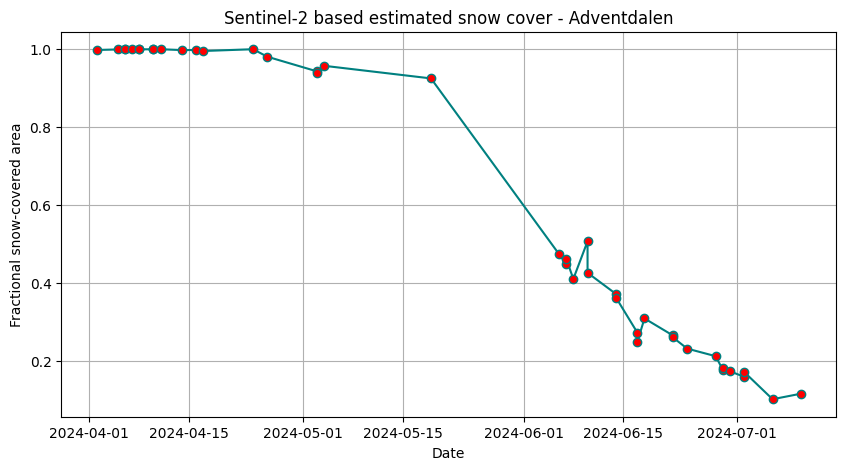

In [157]:
plt.figure(figsize=(10, 5))

plt.plot(df["date"], df["fsca"], marker="o", color="teal", markerfacecolor="red")

plt.xlabel("Date")
plt.ylabel("Fractional snow-covered area")
plt.title("Sentinel-2 based estimated snow cover - Adventdalen")

plt.grid(True)
plt.show()



>  



# Next : Cross sensor comparison ❄

# MODIS (500m) vs. Sentinel-2 (20m)

Set the analysis period for MODIS

In [158]:
START_DATE = "2024-01-01"
END_DATE   = "2024-12-31"

# MODIS Terra + Aqua

Remember that the MODIS sensor is onboard two satellites : Aqua and Terra

MOD10A1 and MYD10A1 are both daily at 500 m snow-cover products

Load and combine both current Collection 6.1 snow products:

In [159]:
modis_terra = (
    ee.ImageCollection("MODIS/061/MOD10A1")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
)

modis_aqua = (
    ee.ImageCollection("MODIS/061/MYD10A1")
    .filterBounds(aoi)
    .filterDate(START_DATE, END_DATE)
)

print("Terra scenes:", modis_terra.size().getInfo())
print("Aqua scenes:", modis_aqua.size().getInfo())

modis_combined = modis_terra.merge(modis_aqua)

print("Combined Terra + Aqua scenes:", modis_combined.size().getInfo())

Terra scenes: 365
Aqua scenes: 365
Combined Terra + Aqua scenes: 730


Display one MODIS scene

In [160]:
modis_image = modis_combined.first()

Map.addLayer(
    modis_image.select("NDSI_Snow_Cover"),
    {
        "min": 0,
        "max": 100,
        "palette": ["black", "cyan", "blue", "white"]
    },
    "MODIS NDSI Snow Cover"
)

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

MOD10A1 and MYD10A1 contain ``` NDSI_Snow_Cover``` with values 0–100 represent the NDSI snow cover index, while larger values identify other classes such as cloud, water, polar night, and no decision, etc.

We extract values between 0-100.

In [161]:
def prepare_modis(image):

    ndsi = image.select("NDSI_Snow_Cover")

    valid = ndsi.gte(0).And(ndsi.lte(100))

    return ndsi.updateMask(valid).rename("ndsi")

modis_ndsi = modis_combined.map(prepare_modis)

# Snow classification : MODIS NDSI to snow/no-snow

In [162]:
MODIS_NDSI_THRESHOLD = 40

def add_modis_snow(image):

    ndsi = image.select("NDSI_Snow_Cover")

    valid = ndsi.gte(0).And(ndsi.lte(100))

    snow = (
        ndsi.gte(MODIS_NDSI_THRESHOLD)
        .updateMask(valid)
        .rename("snow")
    )

    return image.addBands(snow)

modis_snow = modis_combined.map(add_modis_snow)

# Monthly MODIS snow frequency composite

How frequently each 500 m pixel was snow-covered during the month.

$$
\mathrm{F_{snow}} =
\frac{\mathrm{N_{snow}}}
{\mathrm{N_{valid}}}
$$

In [163]:
def monthly_modis_composite(year, month):

    start = ee.Date.fromYMD(year, month, 1)
    end = start.advance(1, "month")

    collection = (
        modis_snow
        .filterDate(start, end)
    )

    snow_frequency = (
        collection
        .select("snow")
        .mean()
        .rename("snow_frequency")
    )

    return snow_frequency.set({
        "year": year,
        "month": month,
        "system:time_start": start.millis()
    })

# Make a collection of monthly composites

In [164]:
months = ee.List.sequence(1, 12)

monthly_modis = ee.ImageCollection.fromImages(
    months.map(
        lambda month:
            monthly_modis_composite(2024, ee.Number(month))
    )
)

print(
    "Monthly MODIS composites:",
    monthly_modis.size().getInfo()
)

Monthly MODIS composites: 12


Let's have a look at April

In [165]:
april_modis = monthly_modis.filter(
    ee.Filter.eq("month", 4)
).first()

Map.centerObject(aoi, 11)

Map.addLayer(april_modis,{
        "min": 0,
        "max": 1,
        "palette": ["brown", "yellow", "lightblue", "white"]
    }, "MODIS April snow frequency")

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

# Calculate the monthly fractional snow-covered area of Adventdalen


In [166]:
def monthly_modis_aoi_fraction(image):

    fraction = (
        image
        .reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=aoi,
            scale=500,
            maxPixels=1e9
        )
        .get("snow_frequency")
    )

    return ee.Feature(
        None,
        {
            "year": image.get("year"),
            "month": image.get("month"),
            "fsca": fraction
        }
    )

modis_monthly_features = monthly_modis.map(monthly_modis_aoi_fraction)

In [167]:
modis_monthly_dict = (
    modis_monthly_features
    .getInfo()
)

modis_monthly_records = [
    feature["properties"]
    for feature in modis_monthly_dict["features"]
]

modis_monthly_df = pd.DataFrame(
    modis_monthly_records
)

modis_monthly_df["date"] = pd.to_datetime(
    modis_monthly_df["year"].astype(str)
    + "-"
    + modis_monthly_df["month"].astype(str)
    + "-01"
)

modis_monthly_df["fsca"] *= 100

modis_monthly_df = modis_monthly_df.sort_values(
    "date"
)

modis_monthly_df

,fsca,month,year,date
0,NaN,1,2024,2024-01-01
1,NaN,2,2024,2024-02-01
2,97.281795,3,2024,2024-03-01
3,99.641906,4,2024,2024-04-01
4,93.496964,5,2024,2024-05-01
5,25.360152,6,2024,2024-06-01
6,4.565392,7,2024,2024-07-01
7,2.474109,8,2024,2024-08-01
8,19.059190,9,2024,2024-09-01
9,96.865476,10,2024,2024-10-01


Let's add the Sentinel-2 retrievals into the analysis!

In [168]:
sentinel_df = df.copy()

sentinel_df["date"] = pd.to_datetime(
    sentinel_df["date"]
)

sentinel_df["fsca"] *= 100

sentinel_monthly_df = (
    sentinel_df
    .set_index("date")
    .resample("MS")["fsca"]
    .mean()
    .reset_index()
)

# Comparison : Sentinel-2 vs. MODIS

In [169]:
comparison = pd.merge(
    sentinel_monthly_df[
        ["date", "fsca"]
    ],
    modis_monthly_df[
        ["date", "fsca"]
    ],
    on="date",
    how="outer",
    suffixes=("_s2", "_modis")
)

comparison

,date,fsca_s2,fsca_modis
0,2024-01-01,NaN,NaN
1,2024-02-01,NaN,NaN
2,2024-03-01,NaN,97.281795
3,2024-04-01,99.781475,99.641906
4,2024-05-01,94.101444,93.496964
5,2024-06-01,32.117211,25.360152
6,2024-07-01,13.612454,4.565392
7,2024-08-01,NaN,2.474109
8,2024-09-01,NaN,19.059190
9,2024-10-01,NaN,96.865476


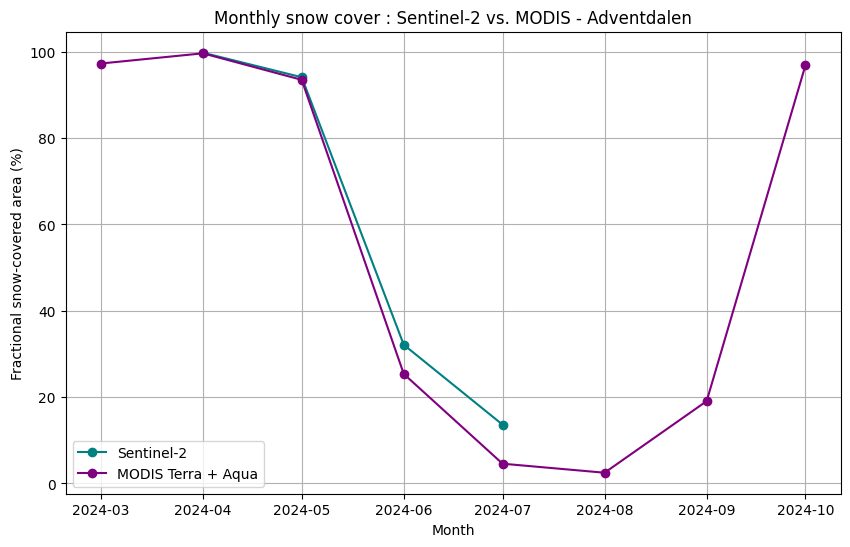

In [170]:
plt.figure(figsize=(10, 6))

plt.plot(
    comparison["date"],
    comparison["fsca_s2"],
    marker="o",
    color="teal",
    label="Sentinel-2"
)

plt.plot(
    comparison["date"],
    comparison["fsca_modis"],
    marker="o",
    color="purple",
    label="MODIS Terra + Aqua"
)

plt.xlabel("Month")
plt.ylabel("Fractional snow-covered area (%)")
plt.title(
    "Monthly snow cover : Sentinel-2 vs. MODIS - Adventdalen"
)

plt.legend()
plt.grid(True)
plt.show()

#Snowmelt changes the spectral signature

**Dry snow:** generally high reflectance in the visible/NIR and strong absorption in SWIR.

**Wet snow:** liquid water changes the spectral response and tends to reduce NIR reflectance.


> NDSI is useful for detecting snow, but NDSI alone does not tell us whether snow is dry or wet


$$
\mathrm{NDSI} = \frac{B3 - B11}{B3 + B11}
$$

where:

- $B3$ = Green band
- $B11$ = SWIR1 band

$$
\rho_{\mathrm{NIR}} = B8
$$

where:

- ρ = spectral reflectance
- $B8$ = NIR band

In [171]:
nir = image.select("B8").divide(10000).rename("NIR")
ndsi = image.normalizedDifference(["B3", "B11"]).rename("NDSI")

Map.addLayer(
    nir,
    {
        "min": 0,
        "max": 0.8,
        "palette": ["black", "purple", "red", "yellow", "white"]
    },
    "Sentinel-2 NIR (B8)"
)

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

Question for everyone:
> Where is the snow? Where is NIR reflectance particularly high?

In [172]:
snow_pixels = ndsi.gt(0.4)
snow_nir = nir.updateMask(snow_pixels)

Map.addLayer(
    snow_nir,
    {
        "min": 0,
        "max": 0.8,
        "palette": ["blue", "cyan", "yellow", "white"]
    },
    "NIR over snow"
)

Map

Map(center=[78.2001443696215, 15.79999999999997], controls=(WidgetControl(options=['position', 'transparent_bg…

# NDSI vs. NIR

Let's sample both variables within the AOI

In [173]:
sample = (
    ee.Image.cat([
        ndsi,
        nir
    ])
    .updateMask(snow_pixels)
    .sample(
        region=aoi,
        scale=20,
        numPixels=5000,
        geometries=False
    )
)

data = sample.getInfo()["features"]

records = [
    feature["properties"]
    for feature in data
]

snow_spectral_df = pd.DataFrame(records)

snow_spectral_df.head()

,NDSI,NIR
0,0.893130,0.6621
1,0.948227,0.6416
2,0.942126,0.7588
3,0.917727,0.7768
4,0.968672,0.7088


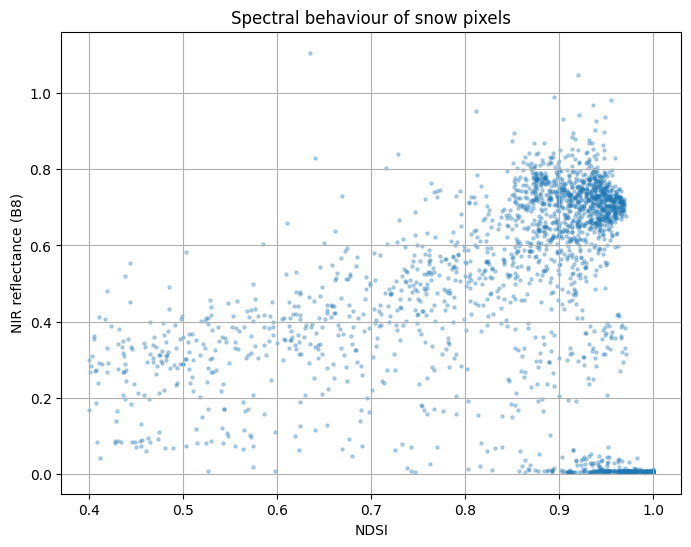

In [174]:
plt.figure(figsize=(8, 6))

plt.scatter(
    snow_spectral_df["NDSI"],
    snow_spectral_df["NIR"],
    s=5,
    alpha=0.3
)

plt.xlabel("NDSI")
plt.ylabel("NIR reflectance (B8)")
plt.title("Spectral behaviour of snow pixels")

plt.grid(True)
plt.show()

Snow is not spectrally homogeneous

In [175]:
EARLY_SEASON_DATE = "2024-05-01"
MELT_SEASON_DATE = "2024-06-01"

def get_sentinel_image(center_date, days=5):

    center = ee.Date(center_date)

    collection = (
        s2
        .filterDate(
            center.advance(-days, "day"),
            center.advance(days + 1, "day")
        )
        .sort("CLOUDY_PIXEL_PERCENTAGE")
    )

    print(
        center_date,
        "available images:",
        collection.size().getInfo()
    )

    return collection.first()

dry_image = get_sentinel_image(EARLY_SEASON_DATE)
wet_image = get_sentinel_image(MELT_SEASON_DATE)


dry_ndsi = dry_image.normalizedDifference(
    ["B3", "B11"]
).rename("NDSI")

dry_nir = (
    dry_image
    .select("B8")
    .divide(10000)
    .rename("NIR")
)

wet_ndsi = wet_image.normalizedDifference(
    ["B3", "B11"]
).rename("NDSI")

wet_nir = (
    wet_image
    .select("B8")
    .divide(10000)
    .rename("NIR")
)

2024-05-01 available images: 4
2024-06-01 available images: 1


Make a function to extract the spectral samples

In [176]:
def sample_snow_spectra(ndsi, nir, aoi, threshold=0.4):

    snow = ndsi.gt(threshold)

    image = ee.Image.cat([
        ndsi,
        nir
    ]).updateMask(snow)

    samples = image.sample(
        region=aoi,
        scale=20,
        numPixels=5000,
        geometries=False
    )

    features = samples.getInfo()["features"]

    records = [
        feature["properties"]
        for feature in features
    ]

    return pd.DataFrame(records)

dry_df = sample_snow_spectra(
    dry_ndsi,
    dry_nir,
    aoi
)

wet_df = sample_snow_spectra(
    wet_ndsi,
    wet_nir,
    aoi
)

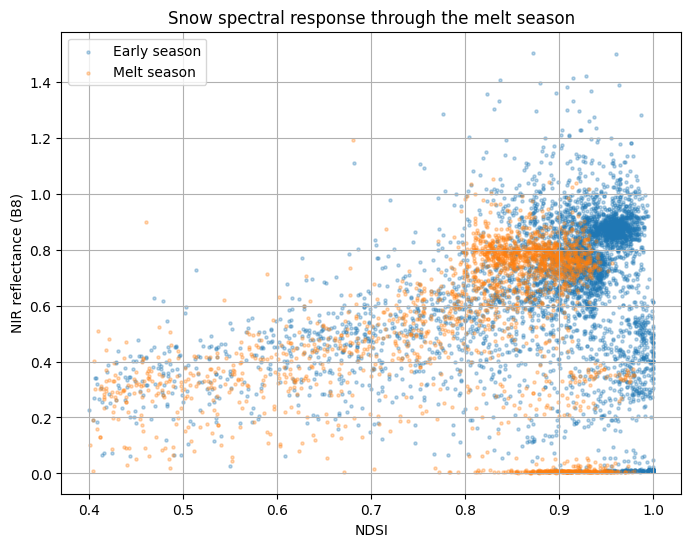

In [177]:
plt.figure(figsize=(8, 6))

plt.scatter(
    dry_df["NDSI"],
    dry_df["NIR"],
    s=5,
    alpha=0.3,
    label="Early season"
)

plt.scatter(
    wet_df["NDSI"],
    wet_df["NIR"],
    s=5,
    alpha=0.3,
    label="Melt season"
)

plt.xlabel("NDSI")
plt.ylabel("NIR reflectance (B8)")
plt.title("Snow spectral response through the melt season")

plt.legend()
plt.grid(True)

plt.show()

Question for everyone:
> Does the spectral distribution of snow change during melt?

*For those interested :* For operational wet/dry snow mapping in Europe, the Copernicus Land Monitoring Service combines Sentinel-2 derived snow extent with **Sentinel-1 radar** to determine wet versus dry snow.